<a href="https://colab.research.google.com/github/necheyberhe/BDA-Homework3-42826/blob/main/HW_3_Version_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework Assignment 3

Using the [Seattle Library Collection Inventory Dataset](https://www.kaggle.com/city-of-seattle/seattle-library-collection-inventory#library-collection-inventory.csv) and Vaex please, answer the following questions:

Important Note: **You can use a reltaviely small subset of the big dataset.**

**Question 1:** Using Vaex, write a function that returns the most popular book in each subject. Use it to find the most popular book in three given subjects (
    e.g., Mystery Fiction_ subject) (15pt)

In [6]:
pip install kaggle

  Using cached bleach-6.3.0-py3-none-any.whl.metadata (31 kB)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached text_unidecode-1.3-py2.py3-none-any.whl.metadata (2.4 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
Using cached bleach-6.3.0-py3-none-any.whl (164 kB)
Using cached python_slugify-8.0.4-py2.py3-none-any.whl (10 kB)
Using cached text_unidecode-1.3-py2.py3-none-any.whl (78 kB)
Using cached webencodings-0.5.1-py2.py3-none-any.whl (11 kB)

   -------------------- ------------------- 3/6 [protobuf]
   -------------------------- ------------- 4/6 [bleach]
   --------------------------------- ------ 5/6 [kaggle]
   --------------------------------- ------ 5/6 [kaggle]
   ---------------------------------------- 6/6 [kaggle]

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "nechiberhe@gmail.com"
os.environ["KAGGLE_KEY"] = "*************"

In [ ]:
import os

# Ensure correct directory
os.chdir(r"d:\Masters Study\2ndyear\BDA\Assignment-3\BDA-Homework3-42826")

# Download dataset
os.system("kaggle datasets download -d city-of-seattle/seattle-library-collection-inventory")

# Unzip it
import zipfile

with zipfile.ZipFile("seattle-library-collection-inventory.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Download and extraction complete")

In [8]:
import os

# Set working directory
os.chdir(r"d:\Masters Study\2ndyear\BDA\Assignment-3\BDA-Homework3-42826")

# Download dataset
os.system("kaggle datasets download -d city-of-seattle/seattle-library-collection-inventory")

0

In [9]:
import zipfile

with zipfile.ZipFile("seattle-library-collection-inventory.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [10]:
import os
print([f for f in os.listdir() if f.endswith(".csv")])

['library-collection-inventory.csv']


In [11]:
import vaex

df = vaex.from_csv("library-collection-inventory.csv", convert=True)
df.head()

#,BibNum,Title,Author,ISBN,PublicationYear,Publisher,Subjects,ItemType,ItemCollection,FloatingItem,ItemLocation,ReportDate,ItemCount
0,3011076,"""A tale of two friends / adapted by Ellie O'Ryan...","O'Ryan, Ellie","'1481425730, 1481425749, 9781481425735, 97814814...",2014.,"Simon Spotlight,","'Musicians Fiction, Bullfighters Fiction, Best f...",jcbk,ncrdr,Floating,qna,2017-09-01T00:00:00.000,1
1,2248846,"'Naruto. Vol. 1, Uzumaki Naruto / story and art ...","Kishimoto, Masashi, 1974-",1569319006,"2003, c1999.","Viz,","'Ninja Japan Comic books strips etc, Comic books...",acbk,nycomic,--,lcy,2017-09-01T00:00:00.000,1
2,3209270,"'Peace, love & Wi-Fi : a ZITS treasury / by Jerr...","Scott, Jerry, 1955-","144945867X, 9781449458676",2014.,"Andrews McMeel Publishing,",'Duncan Jeremy Fictitious character Comic books ...,acbk,nycomic,--,bea,2017-09-01T00:00:00.000,1
3,1907265,The Paris pilgrims : a novel / Clancy Carlile.,"Carlile, Clancy, 1930-",0786706155,c1999.,"Carroll & Graf,","'Hemingway Ernest 1899 1961 Fiction, Biographica...",acbk,cafic,--,cen,2017-09-01T00:00:00.000,1
4,1644616,"'Erotic by nature : a celebration of life, of lo...",--,094020813X,"1991, c1988.","Red Alder Books/Down There Press,","'Erotic literature American, American literature...",acbk,canf,--,cen,2017-09-01T00:00:00.000,1
5,1736505,"""Children of Cambodia's killing fields : memoirs...",--,"0300068395, 0300078730",c1997.,"Yale University Press,","'Political atrocities Cambodia, Children Cambodi...",acbk,canf,--,cen,2017-09-01T00:00:00.000,1
6,1749492,'Anti-Zionism : analytical reflections / editors...,--,091559773X,c1989.,"Amana Books,","'Berger Elmer 1908 1996, Zionism Controversial l...",acbk,canf,--,cen,2017-09-01T00:00:00.000,1
7,3270562,Hard-hearted Highlander / Julia London.,"London, Julia","'0373789998, 037380394X, 9780373789993, 97803738...",[2017],"HQN,","'Man woman relationships Fiction, Betrothal Fict...",acbk,nanew,--,lcy,2017-09-01T00:00:00.000,1
8,3264577,The Sandcastle Empire / Kayla Olson.,"Olson, Kayla","0062484877, 9780062484871",2017.,"HarperTeen,","'Survival Juvenile fiction, Islands Juvenile fic...",acbk,nynew,--,nga,2017-09-01T00:00:00.000,1
9,3236819,'Doctor Who. The return of Doctor Mysterio / BBC...,--,--,[2017],"BBC Worldwide,","'Doctor Fictitious character Drama, Time travel ...",acdvd,nadvd,Floating,wts,2017-09-01T00:00:00.000,2


In [27]:
import vaex

def most_popular_book_per_subject(df, subject_list):
    results = []

    for subject in subject_list:
        # case-insensitive matching (no casting!)
        pattern = f"(?i){subject}"

        df_filtered = df[df["Subjects"].str.contains(pattern, regex=True)]

        if len(df_filtered) == 0:
            results.append((subject, "No matching book found", 0))
            continue

        grouped = df_filtered.groupby(
            by="Title",
            agg={"total_items": vaex.agg.sum("ItemCount")}
        )

        top_pdf = grouped.sort("total_items", ascending=False).head(1).to_pandas_df()

        results.append((
            subject,
            top_pdf.loc[0, "Title"],
            int(top_pdf.loc[0, "total_items"])
        ))

    return results

In [28]:
subjects = [
    "Mystery Fiction",
    "Science Fiction",
    "Fantasy Fiction"
]

results = most_popular_book_per_subject(df, subjects)

for subject, title, count in results:
    print(f"{subject}: {title} ({count} items)")

Mystery Fiction: Origin : a novel / Dan Brown. (3409 items)
Science Fiction: A wrinkle in time / Madeleine L'Engle. (3842 items)
Fantasy Fiction: The power : a novel / Naomi Alderman. (4149 items)


I measured popularity using ItemCount, the number of inventory items associated with each title.
Using ItemCount as the popularity measure:

Mystery Fiction: Origin : a novel / Dan Brown. (3409 items)

Science Fiction: A wrinkle in time / Madeleine L'Engle. (3842 items)
Fantasy Fiction: The power : a novel / Naomi Alderman. (4149 items)



**Question 2**: Using Dask, find the top-10 fiction subjects (5pt), and use Seaborn to visualize the number of items over time for each subject (15pt)
    

In [30]:
pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [31]:
import dask.dataframe as dd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset with Dask

In [32]:
df = dd.read_csv(
    "library-collection-inventory.csv",
    assume_missing=True,
    dtype=str
)

df.head()

,BibNum,Title,Author,ISBN,PublicationYear,Publisher,Subjects,ItemType,ItemCollection,FloatingItem,ItemLocation,ReportDate,ItemCount
0,3011076,A tale of two friends / adapted by Ellie O'Rya...,"O'Ryan, Ellie","1481425730, 1481425749, 9781481425735, 9781481...",2014.,"Simon Spotlight,","Musicians Fiction, Bullfighters Fiction, Best ...",jcbk,ncrdr,Floating,qna,2017-09-01T00:00:00.000,1
1,2248846,"Naruto. Vol. 1, Uzumaki Naruto / story and art...","Kishimoto, Masashi, 1974-",1569319006,"2003, c1999.","Viz,","Ninja Japan Comic books strips etc, Comic book...",acbk,nycomic,<NA>,lcy,2017-09-01T00:00:00.000,1
2,3209270,"Peace, love & Wi-Fi : a ZITS treasury / by Jer...","Scott, Jerry, 1955-","144945867X, 9781449458676",2014.,"Andrews McMeel Publishing,",Duncan Jeremy Fictitious character Comic books...,acbk,nycomic,<NA>,bea,2017-09-01T00:00:00.000,1
3,1907265,The Paris pilgrims : a novel / Clancy Carlile.,"Carlile, Clancy, 1930-",0786706155,c1999.,"Carroll & Graf,","Hemingway Ernest 1899 1961 Fiction, Biographic...",acbk,cafic,<NA>,cen,2017-09-01T00:00:00.000,1
4,1644616,"Erotic by nature : a celebration of life, of l...",<NA>,094020813X,"1991, c1988.","Red Alder Books/Down There Press,","Erotic literature American, American literatur...",acbk,canf,<NA>,cen,2017-09-01T00:00:00.000,1


In [33]:
df.columns

Index(['BibNum', 'Title', 'Author', 'ISBN', 'PublicationYear', 'Publisher',
       'Subjects', 'ItemType', 'ItemCollection', 'FloatingItem',
       'ItemLocation', 'ReportDate', 'ItemCount'],
      dtype='object')

In [34]:
def prepare_fiction_subjects(df,
                             subject_col="Subjects",
                             year_col="PublicationYear",
                             item_col="ItemCount"):
    df = df[[subject_col, year_col, item_col]].dropna()

    df[year_col] = dd.to_numeric(df[year_col], errors="coerce")
    df[item_col] = dd.to_numeric(df[item_col], errors="coerce").fillna(1)

    df = df.dropna(subset=[year_col])
    df = df[(df[year_col] >= 1800) & (df[year_col] <= 2025)]

    df["SubjectList"] = df[subject_col].str.split(",")
    df = df.explode("SubjectList")

    df["Subject"] = df["SubjectList"].str.strip().str.lower()

    fiction_df = df[df["Subject"].str.contains("fiction", na=False)]

    return fiction_df[["Subject", year_col, item_col]]

In [35]:
fiction_df = prepare_fiction_subjects(df)

top10_subjects = (
    fiction_df
    .groupby("Subject")["ItemCount"]
    .sum()
    .nlargest(10)
    .compute()
)

top10_subjects

Subject
['readers primary juvenile fiction', ' reading phonetic method juvenile fiction', ' vocabulary study and teaching primary juvenile fiction', ' english language study and teaching primary juvenile fiction']    16315
['chinese fiction 21st century']                                                                                                                                                                                 14665
['fantasy fiction']                                                                                                                                                                                              10123
['science fiction']                                                                                                                                                                                              10002
['japanese fiction 21st century']                                                                                                   

In [36]:
top_subject_names = top10_subjects.index.tolist()

plot_df = fiction_df[fiction_df["Subject"].isin(top_subject_names)]

items_over_time = (
    plot_df
    .groupby(["PublicationYear", "Subject"])["ItemCount"]
    .sum()
    .reset_index()
    .compute()
)

items_over_time.head()

,PublicationYear,Subject,ItemCount
0,1960.0,['science fiction'],26
1,1970.0,['science fiction'],140
2,1971.0,['fantasy fiction'],93
3,1977.0,['fantasy fiction'],26
4,1984.0,['fantasy fiction'],21


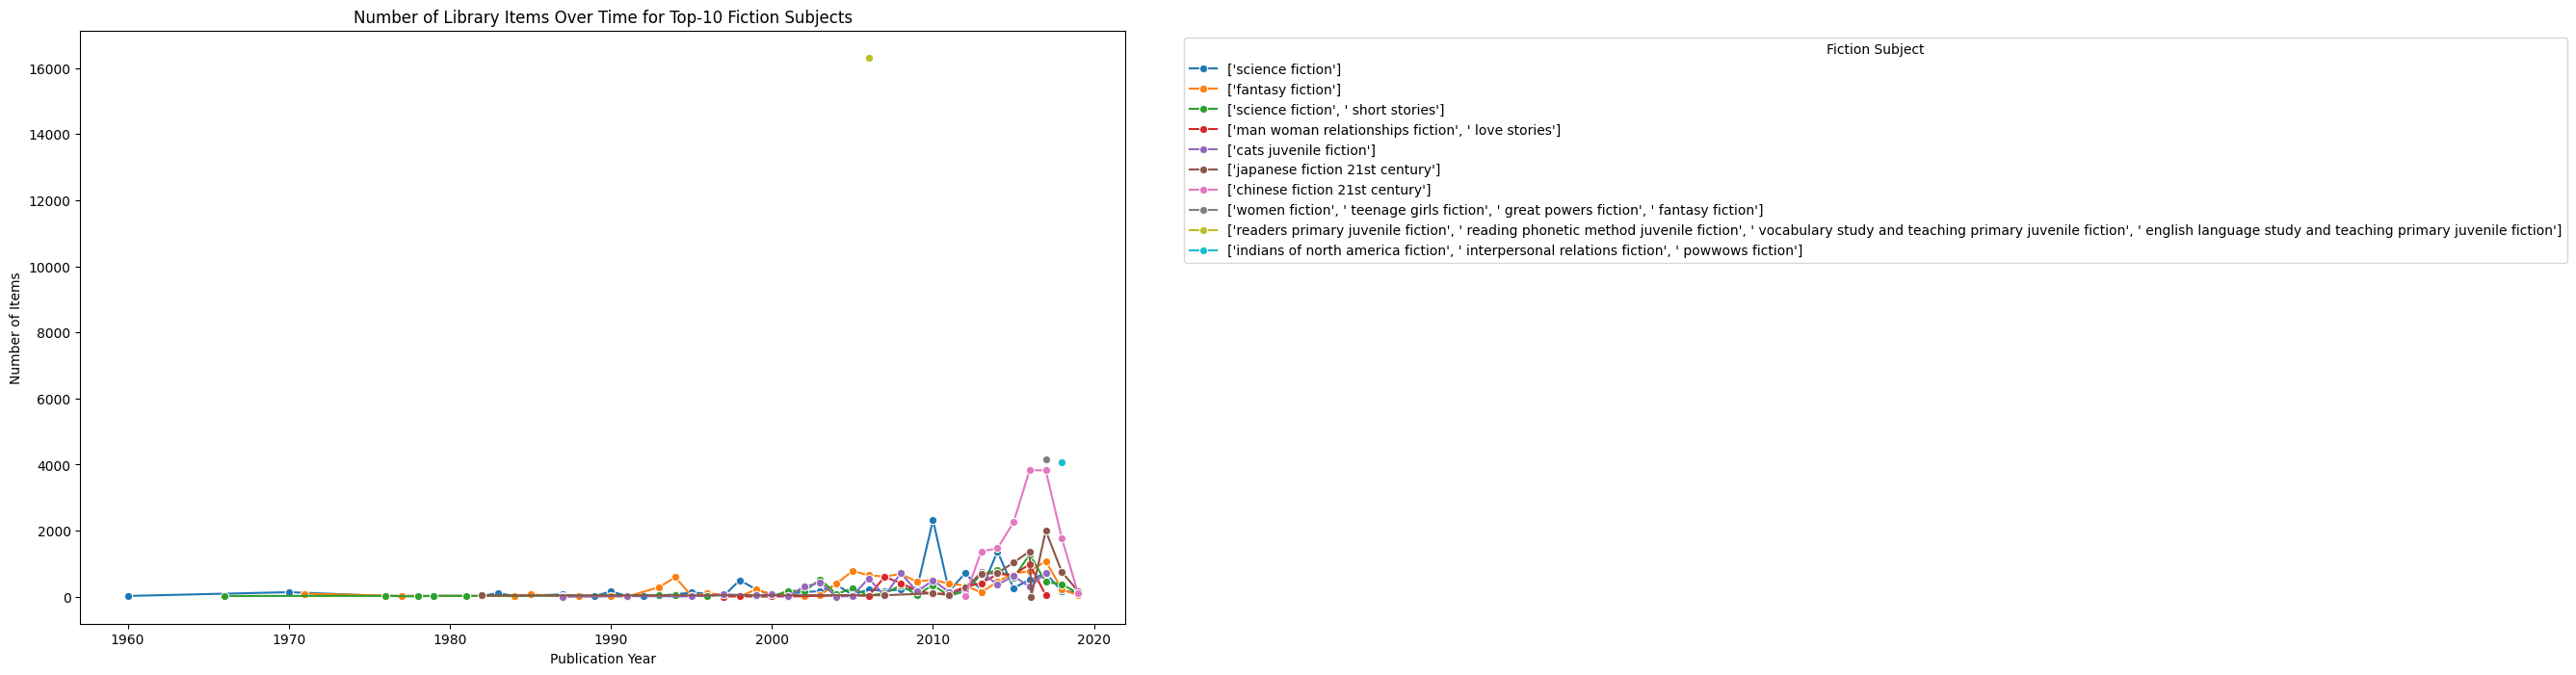

In [38]:
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=items_over_time,
    x="PublicationYear",
    y="ItemCount",
    hue="Subject",
    marker="o"
)

plt.title("Number of Library Items Over Time for Top-10 Fiction Subjects")
plt.xlabel("Publication Year")
plt.ylabel("Number of Items")
plt.legend(title="Fiction Subject", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_29100\1630832943.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


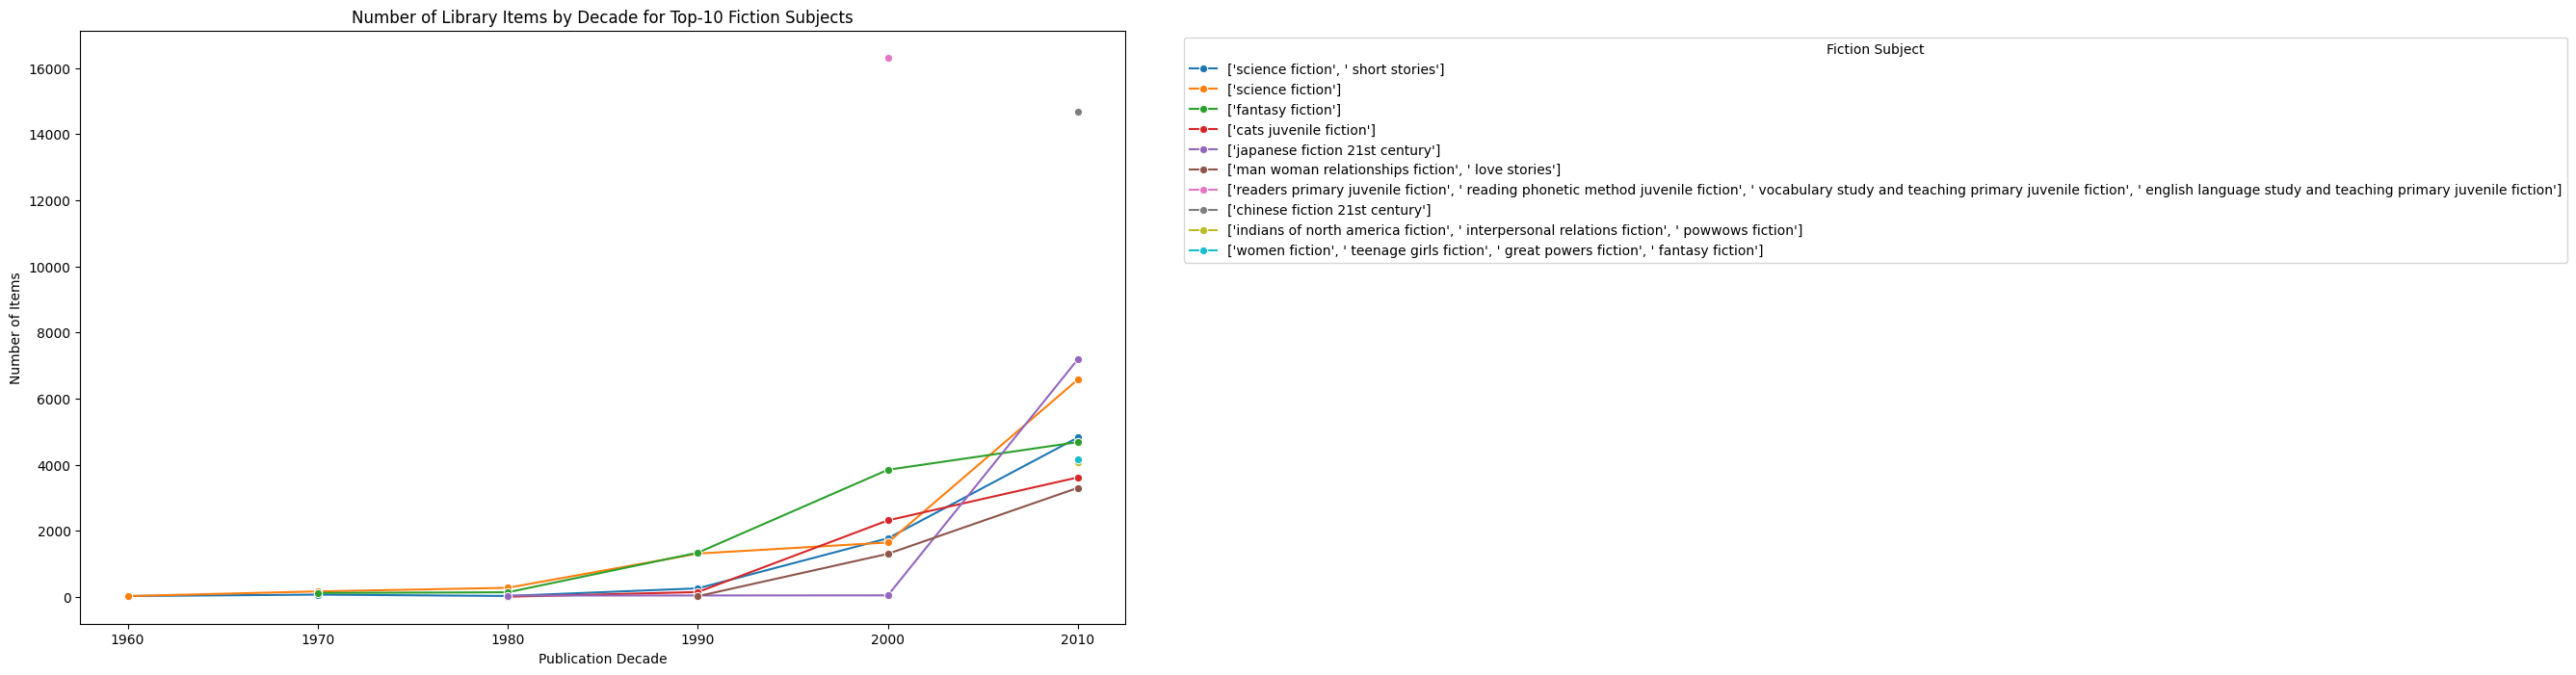

In [39]:
items_over_time["Decade"] = (items_over_time["PublicationYear"] // 10) * 10

decade_df = (
    items_over_time
    .groupby(["Decade", "Subject"], as_index=False)["ItemCount"]
    .sum()
)

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=decade_df,
    x="Decade",
    y="ItemCount",
    hue="Subject",
    marker="o"
)

plt.title("Number of Library Items by Decade for Top-10 Fiction Subjects")
plt.xlabel("Publication Decade")
plt.ylabel("Number of Items")
plt.legend(title="Fiction Subject", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Question 3:** Using Vaex, write a function that gets as input a subject name. The function returns the top-20 most _popular_ authors for the input subject (15pt).



In [ ]:
print(type(df))

<class 'dask.dataframe.core.DataFrame'>


In [43]:
import vaex

vdf = vaex.open("library-collection-inventory.csv.hdf5")
print(type(vdf))

<class 'vaex.dataframe.DataFrameLocal'>


In [50]:
import vaex

def top_20_authors_by_subject(df, subject):
    pattern = f"(?i){subject}"

    df_filtered = df[df["Subjects"].str.contains(pattern, regex=True)]

    # remove missing/invalid authors
    df_filtered = df_filtered[
    (~df_filtered["Author"].isna()) &
    (df_filtered["Author"] != "--") &
    (df_filtered["Author"] != "")
]
    grouped = df_filtered.groupby(
        by=["Author"],
        agg={"total_items": vaex.agg.sum("ItemCount")}
    )

    return grouped.sort("total_items", ascending=False).head(20).to_pandas_df()

In [51]:
top_authors = top_20_authors_by_subject(vdf, "Science Fiction")

for i, row in top_authors.iterrows():
    print(f"{i+1}. {row['Author']} ({int(row['total_items'])} items)")

1. Bendis, Brian Michael (8983 items)
2. Vaughan, Brian K. (6070 items)
3. Dick, Philip K. (5864 items)
4. Card, Orson Scott (5766 items)
5. Gillen, Kieron (5629 items)
6. Weir, Andy (5294 items)
7. Hickman, Jonathan (5205 items)
8. L'Engle, Madeleine (5130 items)
9. Meyer, Marissa (4917 items)
10. Patterson, James, 1947- (4702 items)
11. Scalzi, John, 1969- (4235 items)
12. Le Guin, Ursula K., 1929-2018 (3763 items)
13. Hatke, Ben (3719 items)
14. Roth, Veronica (3465 items)
15. Waid, Mark, 1962- (3418 items)
16. Bradbury, Ray, 1920-2012 (3381 items)
17. Aaron, Jason (3350 items)
18. Remender, Rick (3315 items)
19. Stephenson, Neal (3270 items)
20. Butler, Octavia E. (3226 items)


Popularity was measured by total ItemCount. Missing and placeholder authors were removed before ranking.

Using the [The Blog Authorship Corpus](https://www.kaggle.com/datasets/rtatman/blog-authorship-corpus) and Vaex, please answer the following questions:

**Question 4:** Calculate the average and median age of bloggers in each topic by gender (5pt).
Calculate the average and median age of bloggers according to their sign (5pt).
Visualize the age distributions  of bloggers according to their  topic and gender using Seaborn and PlotlyExpress(15pt)

In [ ]:
import os
os.environ["KAGGLE_USERNAME"] = "nechiberhe@gmail.com"
os.environ["KAGGLE_KEY"] = "**************************"
os.chdir(r"d:\Masters Study\2ndyear\BDA\Assignment-3\BDA-Homework3-42826")

os.system("kaggle datasets download -d rtatman/blog-authorship-corpus")

0

In [56]:
import zipfile

with zipfile.ZipFile("blog-authorship-corpus.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [57]:
import os
print(os.listdir())

['.git', 'blog-authorship-corpus.zip', 'blogtext.csv', 'CollectionInventory_Codes_EXCLUDED_INCLUDED.xlsx', 'HW_3_Version_2.ipynb', 'Library Collection Inventory FAQs.pdf', 'library-collection-inventory.csv', 'library-collection-inventory.csv.hdf5', 'library-collection-inventory.csv.yaml', 'lock', 'README.md', 'seattle-library-collection-inventory.zip', 'socrata_metadata.json']


In [58]:
import dask.dataframe as dd

ddf = dd.read_csv("blogtext.csv")

ddf.head()

,id,gender,age,topic,sign,date,text
0,2059027,male,15,Student,Leo,"14,May,2004","Info has been found (+/- 100 pages,..."
1,2059027,male,15,Student,Leo,"13,May,2004",These are the team members: Drewe...
2,2059027,male,15,Student,Leo,"12,May,2004",In het kader van kernfusie op aarde...
3,2059027,male,15,Student,Leo,"12,May,2004",testing!!! testing!!!
4,3581210,male,33,InvestmentBanking,Aquarius,"11,June,2004",Thanks to Yahoo!'s Toolbar I can ...


In [59]:
ddf.columns

Index(['id', 'gender', 'age', 'topic', 'sign', 'date', 'text'], dtype='object')

Average + median age by topic and gender

In [60]:
def age_stats_by_topic_gender_dask(ddf):
    avg_df = (
        ddf.groupby(["topic", "gender"])["age"]
        .mean()
        .reset_index()
        .rename(columns={"age": "avg_age"})
    )

    median_df = (
        ddf.groupby(["topic", "gender"])["age"]
        .median()
        .reset_index()
        .rename(columns={"age": "median_age"})
    )

    return avg_df.merge(median_df, on=["topic", "gender"]).compute()

In [61]:
stats_topic_gender = age_stats_by_topic_gender_dask(ddf)
stats_topic_gender.head(20)

,topic,gender,avg_age,median_age
0,Accounting,female,32.243570,26.0
1,Accounting,male,23.290909,23.0
2,Advertising,female,27.177740,23.0
3,Advertising,male,29.830091,26.0
4,Agriculture,female,24.548905,24.0
5,Agriculture,male,22.158182,26.0
6,Architecture,female,27.057783,25.0
7,Architecture,male,26.348101,25.0
8,Arts,female,25.503351,24.0
9,Arts,male,24.611687,25.0


2. Average + median age by sign

In [62]:
def age_stats_by_sign_dask(ddf):
    avg_df = (
        ddf.groupby("sign")["age"]
        .mean()
        .reset_index()
        .rename(columns={"age": "avg_age"})
    )

    median_df = (
        ddf.groupby("sign")["age"]
        .median()
        .reset_index()
        .rename(columns={"age": "median_age"})
    )

    return avg_df.merge(median_df, on="sign").compute()

In [63]:
stats_sign = age_stats_by_sign_dask(ddf)
stats_sign

,sign,avg_age,median_age
0,Aquarius,23.537183,24.0
1,Aries,25.184136,24.0
2,Cancer,24.470437,25.0
3,Capricorn,24.098392,24.0
4,Gemini,23.944195,24.0
5,Leo,23.779172,24.0
6,Libra,22.460738,24.0
7,Pisces,25.033319,24.0
8,Sagittarius,23.752478,24.0
9,Scorpio,23.634331,23.0


Seaborn visualization

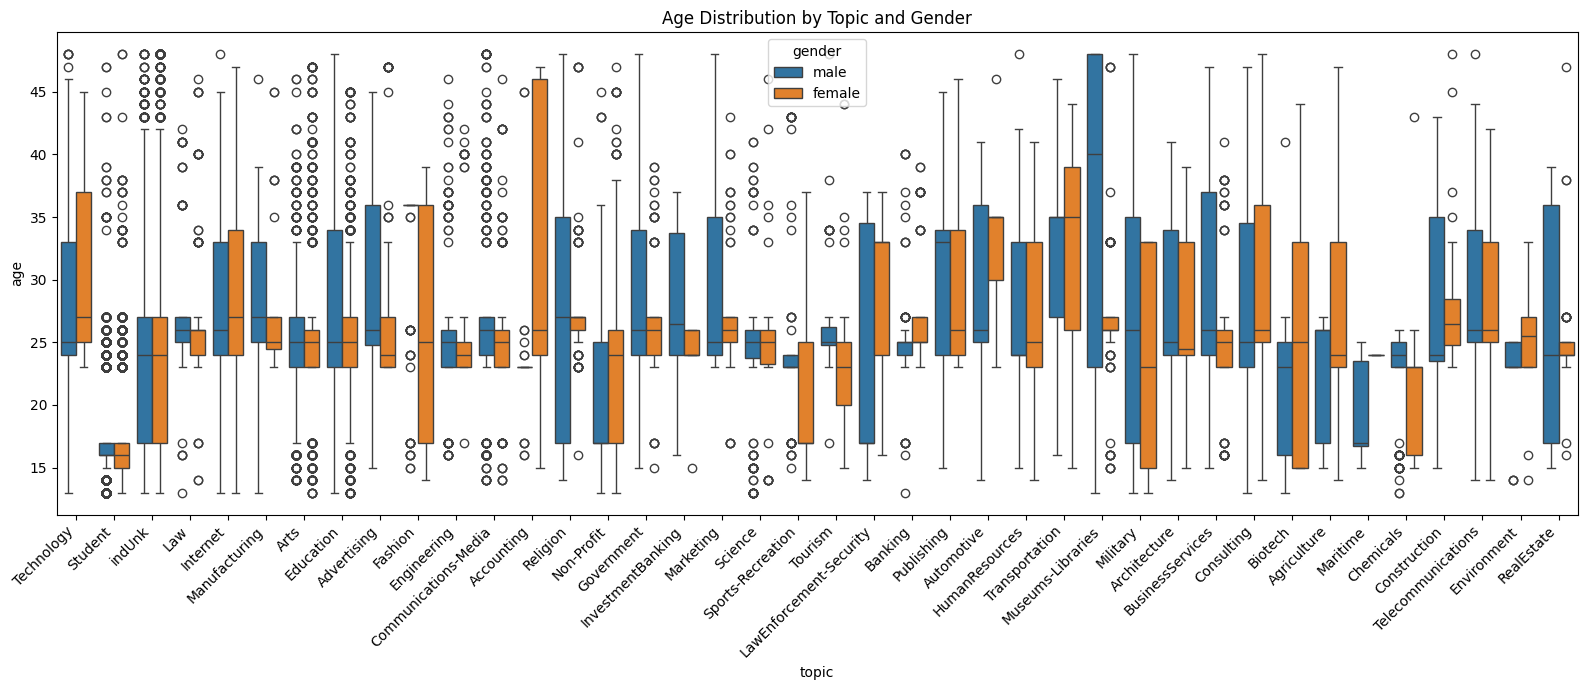

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf_sample = (
    ddf[["age", "topic", "gender"]]
    .sample(frac=0.05, random_state=42)
    .compute()
)

plt.figure(figsize=(16, 7))
sns.boxplot(data=pdf_sample, x="topic", y="age", hue="gender")
plt.xticks(rotation=45, ha="right")
plt.title("Age Distribution by Topic and Gender")
plt.tight_layout()
plt.show()

4. Plotly Express visualization

In [69]:
pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.


In [71]:
pip install ipython

Note: you may need to restart the kernel to use updated packages.


In [76]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

fig = px.box(
    pdf_sample,
    x="topic",
    y="age",
    color="gender",
    title="Age Distribution by Topic and Gender"
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1200,
    height=700
)

fig.show()

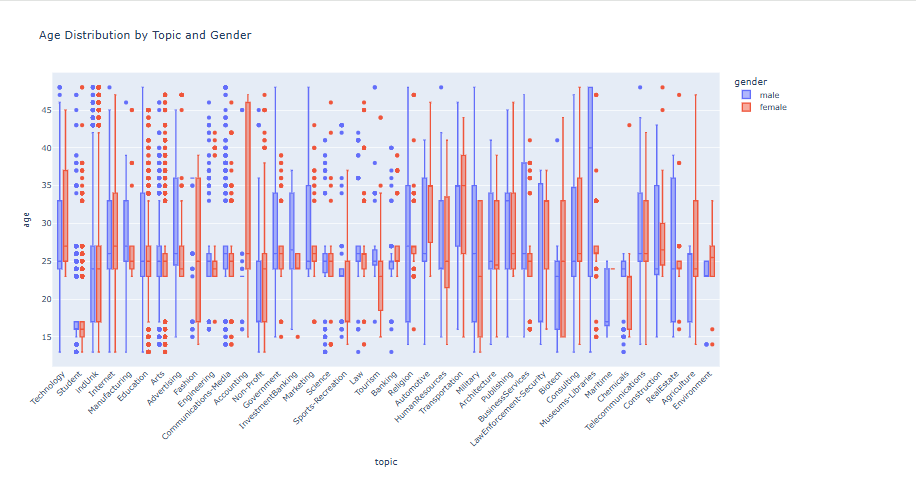

**Question 5:** Using the  [SJR Journal Ranking from 2020 to 2026](https://www.scimagojr.com/journalrank.php) dataset and Seaborn, visualize
    the H-index distributions according to the SJR Best Quartile (15pt). Using a grid, visualize the _Cites / Doc. (2years)_ histograms values of each publisher (10pt). Find an interesting patterns in the data (5pt).

**Note: You can use only the major publishers **
    


In [1]:
import pandas as pd

df = pd.read_csv("scimagojr 2020.csv", sep=';')

cols = ["SJR", "Citations / Doc. (2years)", "H index"]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)                    # ensures .str works
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")  # invalid → NaN

df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_24788\2353642205.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("scimagojr 2020.csv", sep=';')


,Rank,Sourceid,Title,Type,Issn,Publisher,Open Access,Open Access Diamond,SJR,SJR Best Quartile,...,Citations / Doc. (2years),Ref. / Doc.,%Female,Overton,Country,Region,Publisher.1,Coverage,Categories,Areas
0,1,28773,Ca-A Cancer Journal for Clinicians,journal,"15424863, 00079235",John Wiley and Sons Inc,No,No,62.937,Q1,...,131.45,"73,53","51,03",17,United States,Northern America,John Wiley and Sons Inc,1950-2026,Hematology (Q1); Oncology (Q1),Medicine
1,2,19434,MMWR Recommendations and Reports,journal,"10575987, 15458601",Centers for Disease Control and Prevention (CDC),Yes,No,40.949,Q1,...,58.29,"129,20","52,56",3,United States,Northern America,Centers for Disease Control and Prevention (CDC),1990-2025,Epidemiology (Q1); Health Information Manageme...,Environmental Science; Health Professions; Med...
2,3,20315,Nature Reviews Molecular Cell Biology,journal,"14710072, 14710080",Nature Research,No,No,37.461,Q1,...,32.75,"73,21","33,33",12,United Kingdom,Western Europe,Nature Research,2000-2026,Cell Biology (Q1); Molecular Biology (Q1),"Biochemistry, Genetics and Molecular Biology"
3,4,29431,Quarterly Journal of Economics,journal,"00335533, 15314650",Oxford University Press,No,No,34.573,Q1,...,14.72,"68,33","21,37",39,United Kingdom,Western Europe,Oxford University Press,1886-2026,Economics and Econometrics (Q1),"Economics, Econometrics and Finance"
4,5,21100812243,Nature Reviews Materials,journal,20588437,Nature Publishing Group,No,No,32.011,Q1,...,30.36,"107,72","24,05",9,United Kingdom,Western Europe,Nature Publishing Group,2016-2026,"Biomaterials (Q1); Electronic, Optical and Mag...",Energy; Materials Science


H-index distribution by quartile (Seaborn)

In [2]:
df_clean = df.dropna(subset=["H index", "SJR Best Quartile"])

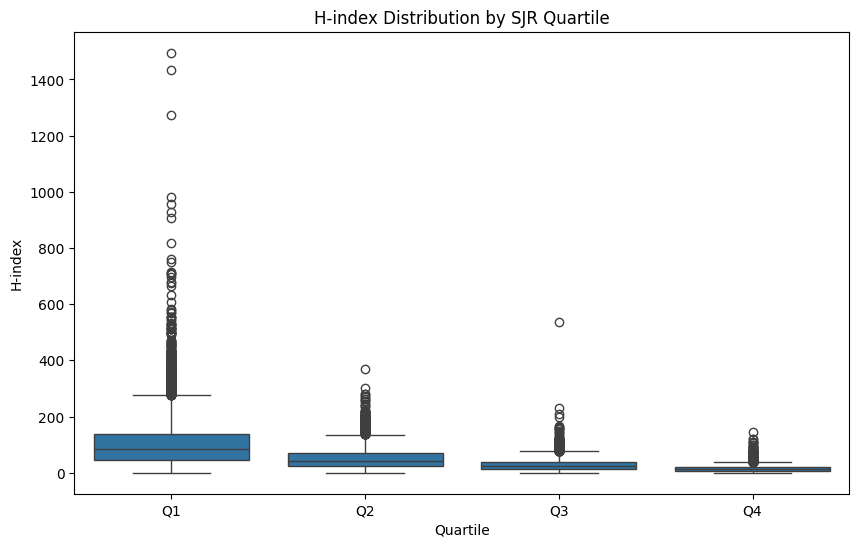

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="SJR Best Quartile",
    y="H index",
    order=["Q1", "Q2", "Q3", "Q4"]
)

plt.title("H-index Distribution by SJR Quartile")
plt.xlabel("Quartile")
plt.ylabel("H-index")
plt.show()

Histogram of Cites/Doc (2 years) by publisher

In [4]:
df["Publisher_clean"] = df["Publisher"].astype(str).str.lower()

df["Publisher_group"] = "Other"

df.loc[df["Publisher_clean"].str.contains("elsevier"), "Publisher_group"] = "Elsevier"
df.loc[df["Publisher_clean"].str.contains("springer|nature"), "Publisher_group"] = "Springer Nature"
df.loc[df["Publisher_clean"].str.contains("wiley"), "Publisher_group"] = "Wiley"
df.loc[df["Publisher_clean"].str.contains("taylor"), "Publisher_group"] = "Taylor & Francis"
df.loc[df["Publisher_clean"].str.contains("sage"), "Publisher_group"] = "SAGE"
df.loc[df["Publisher_clean"].str.contains("oxford"), "Publisher_group"] = "Oxford"

# Keep only major publishers
df_pub = df[df["Publisher_group"] != "Other"]

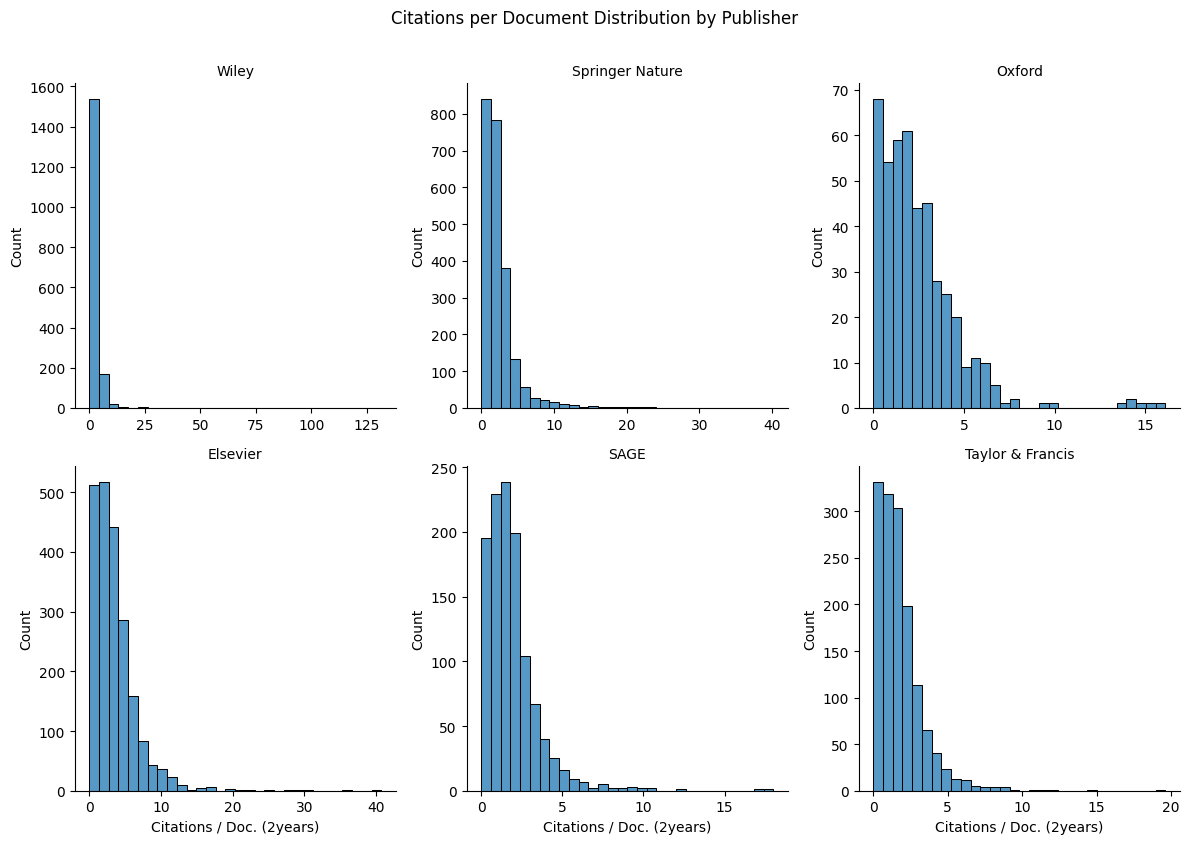

In [6]:
g = sns.FacetGrid(
    df_pub,
    col="Publisher_group",
    col_wrap=3,
    height=4,
    sharex=False,
    sharey=False
)

g.map(sns.histplot, "Citations / Doc. (2years)", bins=30)

g.set_titles("{col_name}")
g.fig.suptitle("Citations per Document Distribution by Publisher", y=1.05)

plt.show()

# Key Patterns observed 
1. Quartile stratification (H-index)

    H-index decreases consistently from Q1 to Q4. Q1 journals have much higher median and variability, indicating impact is concentrated in top-tier journals.

2. Heavy-tailed citation distributions

    All publishers show right-skewed distributions: most journals have low citations, while a few have very high values. This indicates citation inequality.

3. Publisher differences

    Elsevier and Springer Nature have wider spreads and more high-impact outliers, while SAGE and Taylor & Francis show more compact distributions with fewer extremes.
4. Extreme outliers (Wiley)

    Wiley includes rare but very high citation values (100+), which strongly influence the distribution.

The data reveals a highly unequal citation ecosystem, where impact is concentrated in a small number of Q1 journals and amplified by a few high-performing titles within major publishers.